In [1]:
import numpy as np
import pandas as pd
from EMDPM.model_generator import generate_logistic_model
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import (
    plot_biomarker_trajectories,
    plot_true_observations,
    plot_initial_beta_guess,
    plot_theta_fit_comparison,
    plot_theta_error_history,
    plot_beta_overlay,
    plot_beta_error_history,
    plot_lse,
    plot_cog_regression_history
    
    
)
from EMDPM.utils import solve_system
from EMDPM.em_transformer_rework import EM
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

from sklearn.model_selection import GroupKFold, GridSearchCV



In [2]:
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")
n_biomarkers = 10

## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

print("after drop na", df.shape)
subj_counts = df['subj_id'].value_counts()
num_unique = (subj_counts == 1).sum()
print("one time subj_id:", num_unique)

longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])
print("after drop dupes", df.shape)

small_region_set = ['L_inferiorparietal_thickavg','R_inferiorparietal_thickavg','L_inferiortemporal_thickavg','R_inferiortemporal_thickavg',
'L_precuneus_thickavg','R_precuneus_thickavg','L_isthmuscingulate_thickavg','R_isthmuscingulate_thickavg','L_lateraloccipital_thickavg','R_lateraloccipital_thickavg']

small_region_set_resid = ['L_inferiorparietal_thickavg_resid','R_inferiorparietal_thickavg_resid','L_inferiortemporal_thickavg_resid','R_inferiortemporal_thickavg_resid',
'L_precuneus_thickavg_resid','R_precuneus_thickavg_resid','L_isthmuscingulate_thickavg_resid','R_isthmuscingulate_thickavg_resid','L_lateraloccipital_thickavg_resid','R_lateraloccipital_thickavg_resid']

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs_resid = df[small_region_set_resid]
X_obs_resid = X_obs_resid.to_numpy()
X_obs_resid = np.max(X_obs_resid, axis=0) - X_obs_resid

#X_obs = df[small_region_set]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs


print("nans in X:", np.isnan(X_obs).sum())
print("infs in X:", np.isinf(X_obs).sum())

print("nans X_resid:", np.isnan(X_obs_resid).sum())
print("infs X_resid:", np.isinf(X_obs_resid).sum())

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)
print(K.shape, type(K))

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

region_index = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
#K = np.take(np.take(K,region_index,axis=0), region_index, axis=1)

t_max = 30
step = 0.001
print("X.size: ", X_obs.shape, "X_resid.size: ", X_obs_resid.shape)

ids = df["subj_id"].to_numpy()
dt = df["time"].to_numpy()/12 # convert to years
#cog = df["MCATOT"].values#,"TD_score","PIGD_score"]].values
cog = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
nhy = df["NHY"].to_numpy()
print("nans in cog:", np.isnan(cog).sum())
print("infs in cog:", np.isinf(cog).sum())


original size: (880, 250)
after drop na (868, 250)
one time subj_id: 227
after drop dupes (504, 250)
nans in X: 0
infs in X: 0
nans X_resid: 0
infs X_resid: 0
(68, 68) <class 'numpy.ndarray'>
X.size:  (504, 68) X_resid.size:  (504, 10)
nans in cog: 0
infs in cog: 0


In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

def _z(x):
    x = np.asarray(x, float)
    m = np.nanmean(x); s = np.nanstd(x)
    return (x - m) / (s if np.isfinite(s) and s > 0 else 1.0)

def build_severity_index(df):
    moca = _z(df["MCATOT"].to_numpy())        # higher is better
    td   = _z(df["TD_score"].to_numpy())
    pigd = _z(df["PIGD_score"].to_numpy())
    S = (-moca + td + pigd) / 3.0             # higher = worse / later
    return S

def fit_mixedlm_beta_from_clinical(df, ids, dt, t_max, verbose=False, rng=None):

    if rng is None:
        rng = np.random.default_rng(0)

    S = build_severity_index(df)
    dfm = pd.DataFrame({"id": ids, "dt": dt.astype(float), "S": S})
    # keep longitudinal subjects
    good_ids = dfm.groupby("id").size().pipe(lambda s: s[s >= 2]).index
    dfm = dfm[dfm["id"].isin(good_ids)].copy()

    # clean + tiny jitter on dt to avoid exact duplicate rows
    dfm = dfm.replace([np.inf, -np.inf], np.nan).dropna(subset=["id", "dt", "S"])
    dfm["dt"] = dfm["dt"] + 1e-6 * rng.standard_normal(len(dfm))

    # fit: severity ~ dt + (1|id)
    model = smf.mixedlm("S ~ dt", data=dfm, groups=dfm["id"], re_formula="1")
    result = None
    for meth in ("bfgs", "nm"):
        result = model.fit(method=meth, reml=True, maxiter=500, disp=False)
        break

    # get slope k (fixed effect of dt)
    if result is not None and result.converged:
        k = float(result.params.get("dt", np.nan))
    else:
        # fallback OLS for slope if MixedLM fails
        ols = smf.ols("S ~ dt", data=dfm).fit()
        k = float(ols.params.get("dt", np.nan))

    if not np.isfinite(k) or abs(k) < 1e-8:
        # if slope is (near) zero, default to small positive slope to avoid blow-up
        if verbose:
            print("[MixedLM] slope near zero; using fallback k=1.0")
        k = 1.0

    # random intercepts u_i
    re = {}
    if result is not None and hasattr(result, "random_effects"):
        re = {pid: float(eff.get("Group", 0.0)) for pid, eff in result.random_effects.items()}

    unique_ids = np.unique(ids)
    beta_raw = np.array([re.get(pid, 0.0) / k for pid in unique_ids], dtype=float)

    # shift & clip: make the smallest beta zero, cap at t_max
    beta_shift = beta_raw - np.nanmin(beta_raw)
    initial_beta = np.clip(beta_shift, 0.0, t_max)

    pid_to_beta = {pid: initial_beta[i] for i, pid in enumerate(unique_ids)}

    if verbose:
        print("β_init summary:", pd.Series(initial_beta).describe())

    return initial_beta, pid_to_beta, result


β_init summary: count    146.000000
mean      15.382218
std        7.184087
min        0.000000
25%        9.586120
50%       15.547792
75%       20.682332
max       30.000000
dtype: float64


DescribeResult(nobs=146, minmax=(0.0, 30.0), mean=15.382218227454752, variance=51.611101147601296, skewness=0.15504991393777867, kurtosis=-0.6700496594783982)

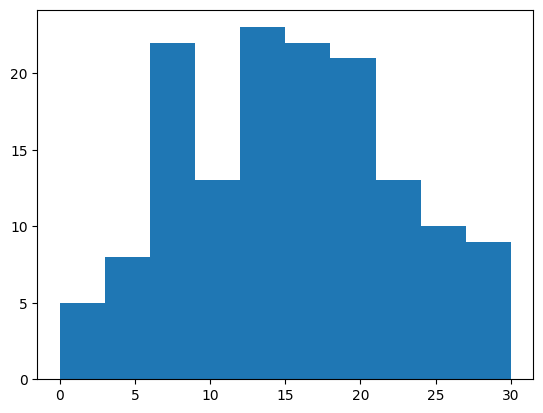

In [4]:
initial_beta, pid_to_beta, _ = fit_mixedlm_beta_from_clinical(
    df=df, ids=ids, dt=dt, t_max=t_max, verbose=True
)



plt.hist(initial_beta)

from scipy import stats
stats.describe(initial_beta)


,x,y,pearson,spearman
0,dt,Severity S,0.090344,0.078553
1,s=dt+beta,Severity S,0.815185,0.812554
2,dt,MCATOT,-0.029129,-0.021668
3,s=dt+beta,MCATOT,-0.578766,-0.571864
4,dt,TD_score,-0.023679,-0.048847
5,s=dt+beta,TD_score,0.484933,0.449582
6,dt,PIGD_score,0.165815,0.132047
7,s=dt+beta,PIGD_score,0.481651,0.445155


R²(S ~ dt): 0.008   |   R²(S ~ s): 0.665   |   Δ: +0.656


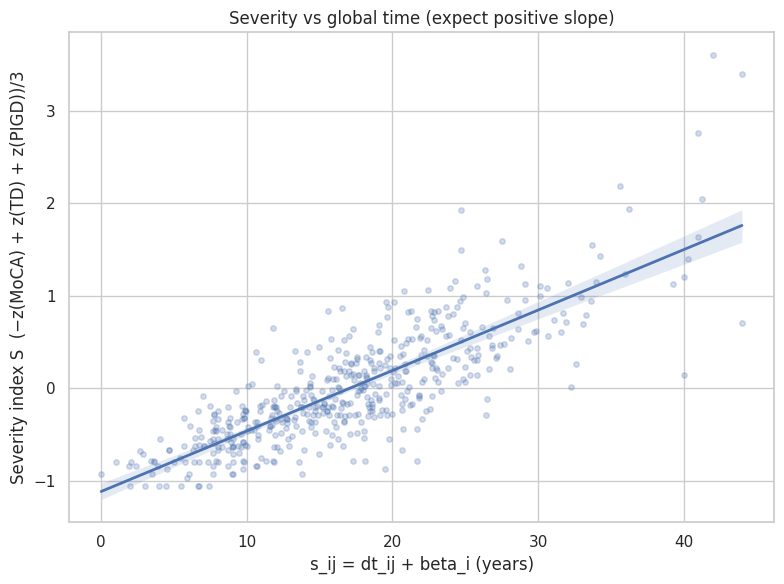

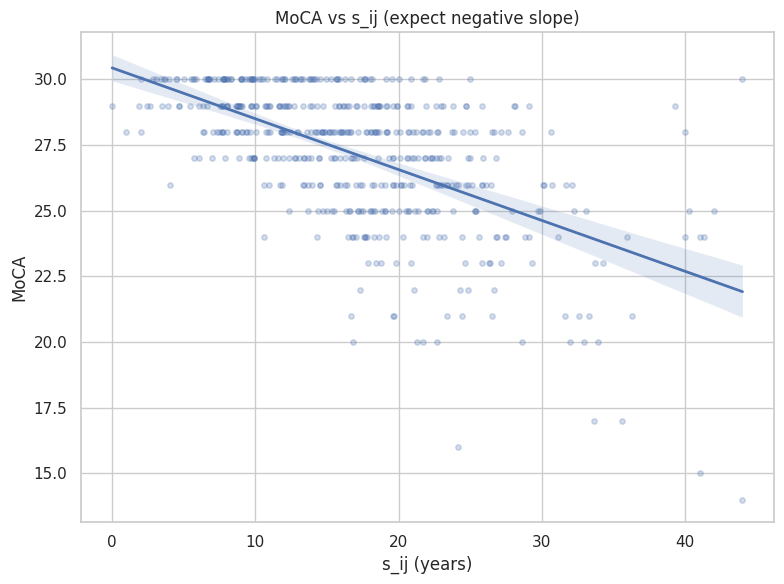

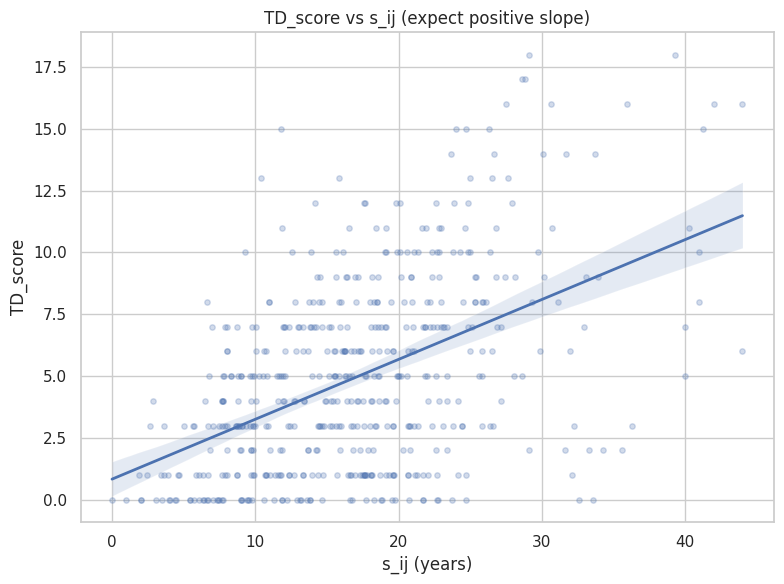

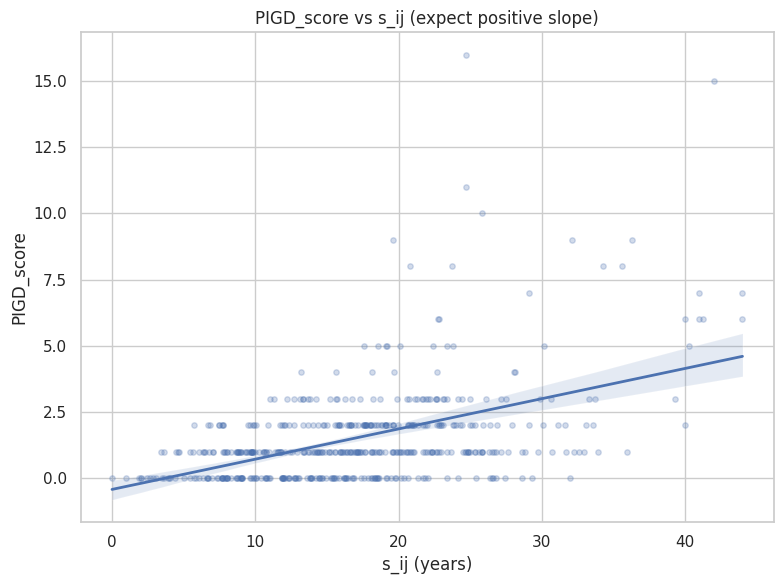

/tmp/ipykernel_9610/3432608259.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df["NHY"], y=s, palette="plasma", inner="box")


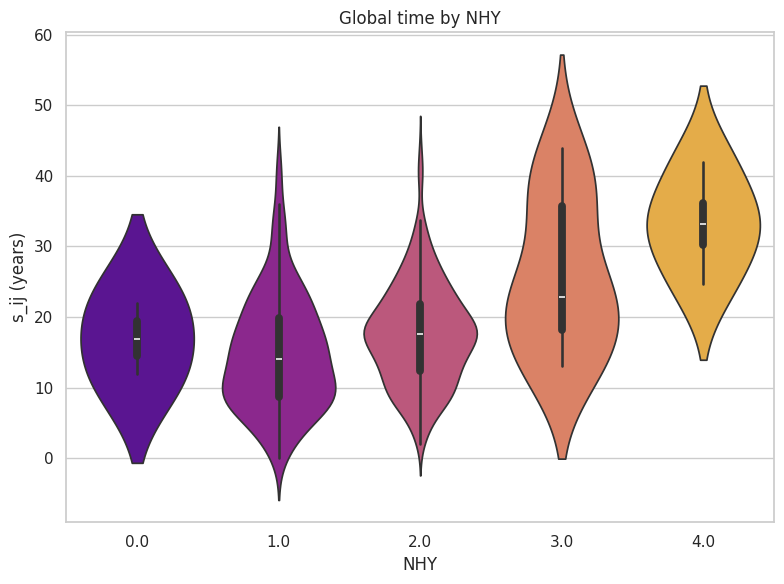

In [15]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr

# 1) s_ij = dt + beta_i  (map per-patient beta to each visit)
unique_ids = np.unique(ids)
pid_to_idx = {pid:i for i, pid in enumerate(unique_ids)}
beta_all = np.array([initial_beta[pid_to_idx[pid]] for pid in ids], dtype=float)
s = dt + beta_all  # global time per visit

# 2) Build a simple severity index S (higher = worse)
def z(x):
    x = np.asarray(x, float)
    m, sd = np.nanmean(x), np.nanstd(x)
    return (x - m) / (sd if sd > 0 else 1.0)

S = (-z(df["MCATOT"].to_numpy()) + z(df["TD_score"].to_numpy()) + z(df["PIGD_score"].to_numpy())) / 3.0

# 3) Correlation table: compare dt vs s
def corr_pair(x, y, namex, namey):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return {"x":namex,"y":namey,"pearson":np.nan,"spearman":np.nan}
    return {
        "x": namex,
        "y": namey,
        "pearson": pearsonr(x[mask], y[mask])[0],
        "spearman": spearmanr(x[mask], y[mask]).correlation
    }

rows = []
rows += [corr_pair(dt, S, "dt", "Severity S"),
         corr_pair(s,  S, "s=dt+beta", "Severity S"),
         corr_pair(dt, df["MCATOT"].to_numpy(), "dt", "MCATOT"),
         corr_pair(s,  df["MCATOT"].to_numpy(), "s=dt+beta", "MCATOT"),
         corr_pair(dt, df["TD_score"].to_numpy(), "dt", "TD_score"),
         corr_pair(s,  df["TD_score"].to_numpy(), "s=dt+beta", "TD_score"),
         corr_pair(dt, df["PIGD_score"].to_numpy(), "dt", "PIGD_score"),
         corr_pair(s,  df["PIGD_score"].to_numpy(), "s=dt+beta", "PIGD_score")]
corr_df = pd.DataFrame(rows)
display(corr_df)

# 4) R² comparison (OLS): dt -> S  vs  s -> S
maskS = np.isfinite(S) & np.isfinite(dt) & np.isfinite(s)
X_dt = sm.add_constant(dt[maskS])
X_s  = sm.add_constant(s[maskS])
y    = S[maskS]
r2_dt = sm.OLS(y, X_dt).fit().rsquared
r2_s  = sm.OLS(y, X_s ).fit().rsquared
print(f"R²(S ~ dt): {r2_dt:.3f}   |   R²(S ~ s): {r2_s:.3f}   |   Δ: {r2_s - r2_dt:+.3f}")

# 5) Plots — one figure each (no subplots)
sns.set(style="whitegrid", rc={"figure.figsize":(8,6)})

# Scatter with regression: S vs s
plt.figure()
sns.regplot(x=s, y=S, scatter_kws=dict(alpha=0.25, s=15), line_kws=dict(lw=2))
plt.xlabel("s_ij = dt_ij + beta_i (years)")
plt.ylabel("Severity index S  (−z(MoCA) + z(TD) + z(PIGD))/3")
plt.title("Severity vs global time (expect positive slope)")
plt.tight_layout()
plt.show()

# Scatter with regression: each clinical vs s
for name, y, sign in [("MoCA", df["MCATOT"].to_numpy(), "negative"),
                      ("TD_score", df["TD_score"].to_numpy(), "positive"),
                      ("PIGD_score", df["PIGD_score"].to_numpy(), "positive")]:
    plt.figure()
    sns.regplot(x=s, y=y, scatter_kws=dict(alpha=0.25, s=15), line_kws=dict(lw=2))
    plt.xlabel("s_ij (years)")
    plt.ylabel(name)
    plt.title(f"{name} vs s_ij (expect {sign} slope)")
    plt.tight_layout()
    plt.show()

# 6) Violin: s by NHY (later NHY should have larger s)
plt.figure(figsize=(8,6))
sns.violinplot(x=df["NHY"], y=s, palette="plasma", inner="box")
plt.xlabel("NHY")
plt.ylabel("s_ij (years)")
plt.title("Global time by NHY")
plt.tight_layout()
plt.show()


In [4]:
def create_patient_list(X_obs, ids, dt, cog, initial_beta=None):
    unique_ids = np.unique(ids)
    id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_data = {
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
        }
        if initial_beta is not None:
            patient_data["initial_beta"] = initial_beta[id_to_index[pid]]
        patient_list.append(patient_data)

    return patient_list

X = create_patient_list(X_obs, ids, dt, cog, initial_beta)

In [5]:
# there are 504 obs and ~150 patients
# X = {
#     "X_obs": X_obs,       # (n_obs, n_biomarkers)
#     "dt": dt,             # (n_obs,)
#     "ids": ids,           # (n_obs,)
#     "cog": cog,           # (n_obs, n_cog_features)
#     "K": K,               # (n_biomarkers, n_biomarkers)
#     "initial_beta": initial_beta  # (n_patients,)
# }
from sklearn.metrics import make_scorer

# Define this in a code cell before GridSearchCV
def unsupervised_em_scorer(estimator, X, y=None):
    try:
        score = estimator.score(X)
        print(f"[GridSearchCV] score = {score:.4f}")
        return score
    except Exception as e:
        print(f"[GridSearchCV ERROR]: {e}")
        return float("-inf")

unsupervised_scorer = make_scorer(unsupervised_em_scorer, greater_is_better=True)



model = EM(K=K)
param_grid = {
    "lambda_f": [0.01, 0.1, 0.3, 0.5, 0.7, 1.0],
    "lambda_cog": [0.01, 0.1, 0.3, 0.5, 0.7, 1.0],
    "lambda_scalar": [0.01, 0.1, 0.3, 0.5, 0.7, 1.0],
    "jac_toggle": [True],
    "max_iter": [20],
}
groups = [p["id"] for p in X]

gkf = GroupKFold(n_splits=3)
grid = GridSearchCV(model, param_grid, cv=gkf, scoring = None, n_jobs=15)#scoring=unsupervised_scorer)
grid.fit(X=X, y=None, groups=groups);

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)


  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

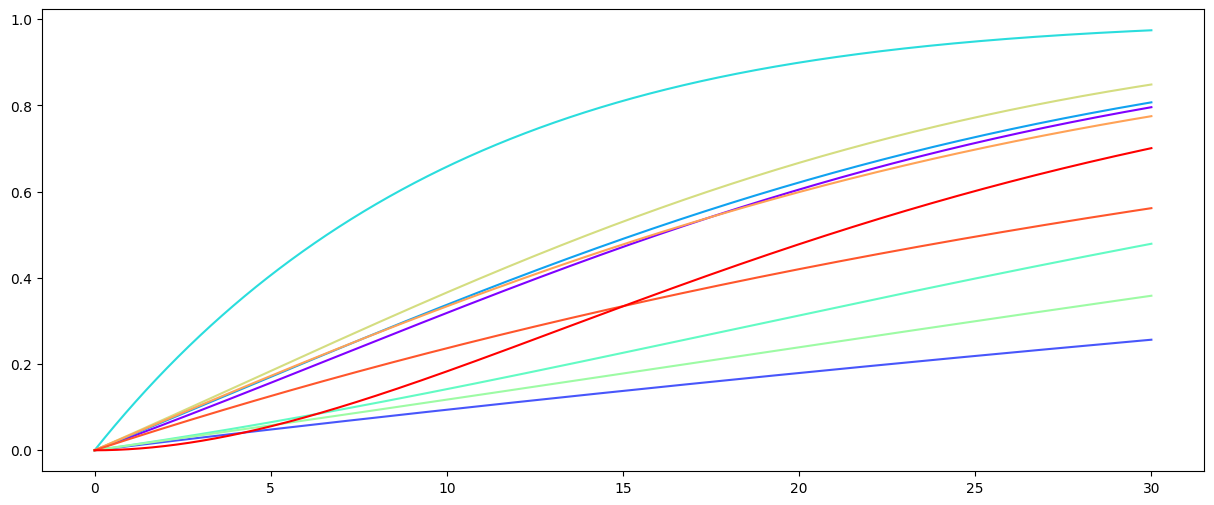

initial theta:
f:  [0.021 0.015 0.066 0.068 0.093 0.075 0.093 0.095 0.087 0.001]
s:  [1.299 2.487 0.166 0.503 2.96  2.982 2.482 2.546 1.264 2.035]
s_k:  0.9870000000000001
final theta:
f:  [0.03  0.01  0.034 0.102 0.012 0.011 0.036 0.035 0.027 0.   ]
s:  [0.761 2.458 0.779 0.408 1.587 2.009 1.316 1.542 0.994 1.04 ]
s_k:  0.1498418125352666

BETA SUMMARY:
beta initial:  [27.34  14.169 26.668 28.183 25.236 23.508 10.071 23.979 23.418 24.042]
beta final:  [11.726 12.    10.89  10.72  12.    12.    12.    11.134 12.    11.263]


In [ ]:
t_span = np.linspace(0, t_max, int(t_max/step))

best_model = grid.best_estimator_

theta_history = best_model.theta_history
beta_history = best_model.beta_history
lse_history = best_model.lse_history

initial_theta = theta_history[:,0]
initial_x0 = np.zeros(n_biomarkers)
initial_f = initial_theta[0:n_biomarkers]
initial_s = initial_theta[n_biomarkers:2*n_biomarkers]
initial_scalar_K = initial_theta[-1]
#initial_model = solve_system(initial_x0, initial_f, K, t_span, initial_scalar_K)

# final params
final_theta = theta_history[:,-1]
final_x0 = np.zeros(n_biomarkers)
final_f = final_theta[0:n_biomarkers]
final_s = final_theta[n_biomarkers:2*n_biomarkers]
final_scalar_K = final_theta[-1]
final_model = solve_system(final_x0, final_f, K, t_span, final_scalar_K)

plt.figure(figsize=(15,6))
colors = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))
for b in range(n_biomarkers):
    plt.plot(t_span, final_model[b], color = colors[b])
plt.show()

print("initial theta:")
print("f: ", np.round(initial_theta[:n_biomarkers], 3)[0:10])
print("s: ", np.round(initial_theta[n_biomarkers:2*n_biomarkers], 3)[0:10])
print("s_k: ", initial_theta[-1])

print("final theta:")
print("f: ", np.round(final_theta[:n_biomarkers], 3)[0:10])
print("s: ", np.round(final_theta[n_biomarkers:2*n_biomarkers], 3)[0:10])
print("s_k: ", final_theta[-1])

## Beta comparison:
print("\nBETA SUMMARY:")
print("beta initial: ", np.round(beta_history[0:10, 0], 3))
print("beta final: ", np.round(beta_history[0:10, -1], 3))

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

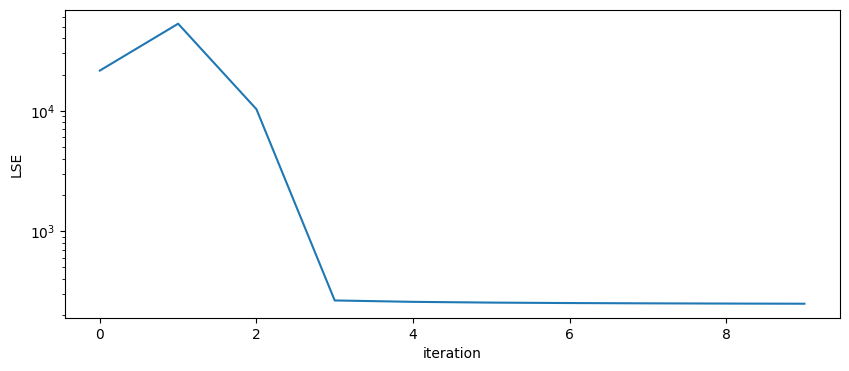

248.7633728713369


In [ ]:
plot_lse(lse_history)
print(lse_history[-1])
# plt.figure()
# plt.plot(lse_history[1:-1])
# plt.yscale('log')
# plt.show()

Unique PIDs: [3102 3105 3107 3108 3111 3113 3116 3118 3119 3120 3122 3123 3124 3125
 3126 3127 3128 3130 3131 3132 3134 3150 3154 3166 3173 3174 3175 3176
 3178 3179 3181 3182 3184 3185 3190 3305 3307 3308 3309 3314 3321 3323
 3325 3327 3328 3352 3354 3359 3360 3364 3365 3366 3367 3371 3372 3373
 3374 3375 3377 3378 3380 3383 3385 3386 3387 3392 3500 3552 3556 3557
 3558 3559 3564 3567 3574 3575 3577 3584 3585 3586 3587 3588 3591 3592
 3593 3752 3757 3758 3760 3762 3763 3770 3771 3775 3776 3777 3778 3780
 3781 3787 3789 3800 3802 3808 3814 3815 3818 3819 3822 3823 3824 3825
 3826 3828 3829 3830 3831 3832 3834 3835 3838 3863 3866 3868 3869 3870
 4001 4005 4011 4012 4013 4019 4020 4021 4022 4024 4025 4026 4027 4029
 4030 4034 4035 4037 4038 4136]
Counts: [2 4 4 4 2 3 3 4 2 4 2 3 4 4 3 2 3 3 3 4 3 3 4 3 3 4 4 2 4 4 3 3 3 3 4 2 4
 4 4 2 3 3 4 4 4 4 4 4 4 4 4 3 4 4 4 4 3 3 4 3 4 2 2 3 4 4 2 4 4 4 3 4 2 4
 3 4 3 2 4 4 3 4 3 3 4 3 4 3 4 3 4 3 2 4 4 4 4 4 3 3 4 4 4 4 4 4 3 4 4 4 4
 4 4 3 4 4 4

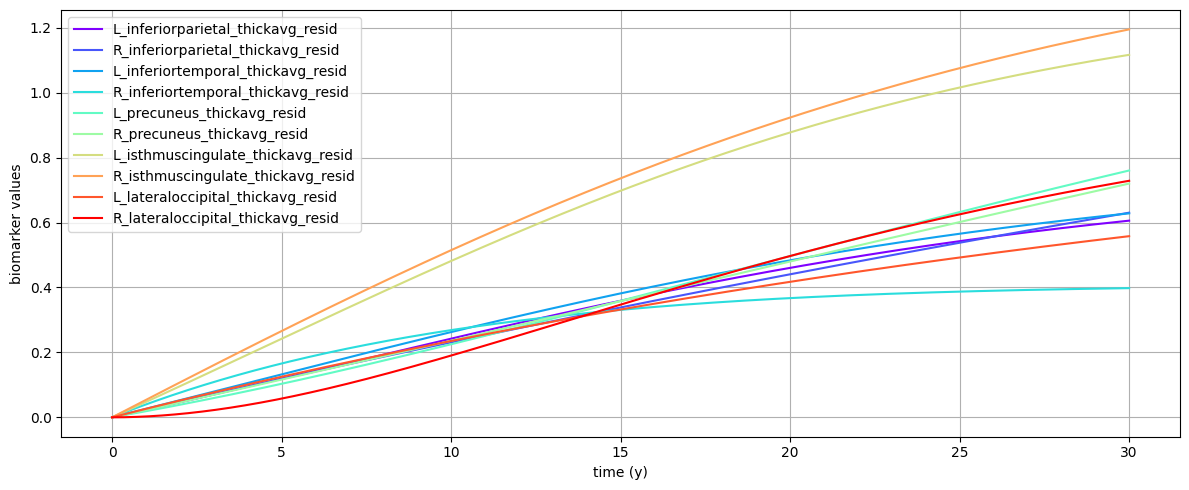

In [ ]:
from sklearn.linear_model import LinearRegression

def plot_trajectories_with_patient_regression(X, dt, ids, beta, t_span, model, patient_id, biomarker_labels=None):

    n_biomarkers = model.shape[0]
    patient_mask = (ids == patient_id)
    
    X_i = X[patient_mask, :]
    print(X_i)
    dt_i = dt[patient_mask]
    beta_i = beta[np.unique(ids).tolist().index(patient_id)]
    t_ij = dt_i + beta_i 
    fig, ax = plt.subplots(figsize=(12, 5))
    
    
    for j in range(n_biomarkers):
        label = biomarker_labels[j]
        color = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))    

        ax.plot(t_span, model[j], label=label, color=color[j])        

    ax.set_xlabel("time (y)")
    ax.set_ylabel("biomarker values")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

unique_pids, counts = np.unique(ids, return_counts=True)
modal_pid = unique_pids[np.argmax(counts)]

print("Unique PIDs:", unique_pids)
print("Counts:", counts)
print("Modal PID:", modal_pid)

print(len(np.unique(ids)))
print(len(beta_history[:,-1]))
s = final_theta[n_biomarkers:2*n_biomarkers]

plot_trajectories_with_patient_regression(X_obs, dt, ids, beta_history[:,-1], t_span, final_model*s[:,None], ids[5], small_region_set_resid)

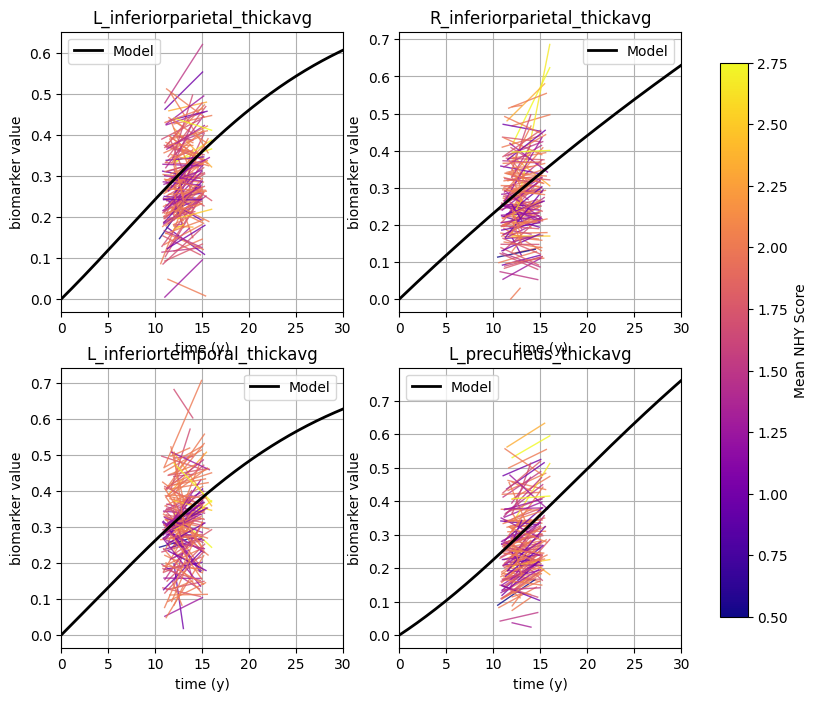

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import math
import matplotlib.cm as cm
import matplotlib.colors as colors

def plot_all_patient_regression_lines_grid_nhy(X, dt, ids, beta, t_span, nhy, model=None,
                                               biomarker_indices=None, biomarker_labels=None,
                                               max_lines=500, t_max=40):
    """
    Plot regression lines per patient for each selected biomarker on a grid of subplots.
    Each line is color-coded by the patient's mean NHY score.
    """
    if biomarker_indices is None:
        biomarker_indices = list(range(X.shape[1]))

    unique_ids = np.unique(ids)
    pid_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    # Compute mean NHY score per patient
    mean_nhy = {}
    for pid in unique_ids:
        nhy_i = nhy[ids == pid]
        mean_nhy[pid] = np.mean(nhy_i) if len(nhy_i) > 0 else np.nan

    # Colormap setup
    cmap = cm.plasma  # or viridis, inferno, etc.
    nhy_vals = np.array(list(mean_nhy.values()))
    norm = colors.Normalize(vmin=np.nanmin(nhy_vals), vmax=np.nanmax(nhy_vals))

    n_plots = len(biomarker_indices)
    n_cols = math.ceil(np.sqrt(n_plots))
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    axes = axes.flatten()

    for plot_idx, j in enumerate(biomarker_indices):
        ax = axes[plot_idx]
        title = biomarker_labels[j] if biomarker_labels else f"biomarker {j}"
        ax.set_title(f"{title}")
        ax.set_xlabel("time (y)")
        ax.set_ylabel("biomarker value")

        line_count = 0
        for pid in unique_ids:
            if line_count >= max_lines:
                break
            mask = (ids == pid)
            if np.sum(mask) < 2:
                continue

            X_i = X[mask, j]
            dt_i = dt[mask]
            beta_i = beta[pid_to_index[pid]]
            t_ij = dt_i + beta_i

            nhy_mean = mean_nhy[pid]
            if np.isnan(nhy_mean):
                continue
            line_color = cmap(norm(nhy_mean))

            model_i = LinearRegression().fit(t_ij.reshape(-1, 1), X_i)
            t_fit = np.linspace(t_ij.min(), t_ij.max(), 20)
            x_fit = model_i.predict(t_fit.reshape(-1, 1))

            ax.plot(t_fit, x_fit, color=line_color, alpha=0.8, linewidth=1)
            line_count += 1

        # Plot model-predicted trajectory
        if model is not None:
            ax.plot(t_span, model[j], color='black', linewidth=2, label="Model")
            ax.legend()

        ax.grid(True)
        ax.set_xlim(0, t_max)

    # Remove unused axes
    for k in range(n_plots, len(axes)):
        fig.delaxes(axes[k])

    # Add colorbar for NHY scale
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='vertical', shrink=0.9)
    cbar.set_label("Mean NHY Score")

    plt.show()

plot_all_patient_regression_lines_grid_nhy(
    X=X_obs,
    dt=dt,
    ids=ids,
    beta=beta_history[:, -1],
    t_span=t_span,
    nhy=nhy,  # your NHY array
    model=final_model * s[:, None],
    biomarker_indices=[0, 1, 2, 4],
    biomarker_labels=small_region_set,
    max_lines=500,
    t_max=t_span[-1]
)


/tmp/ipykernel_14919/4096345311.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")


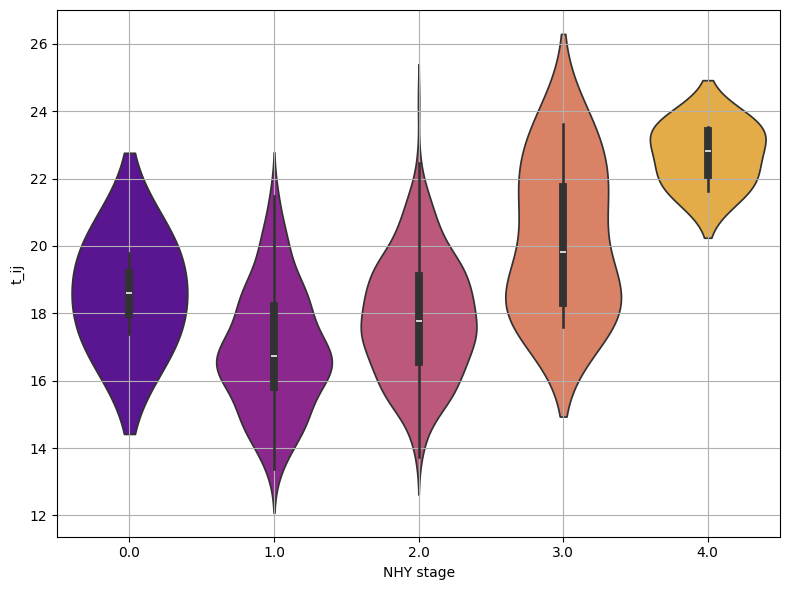

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_violin_nhy_vs_tij(dt, ids, beta, nhy):
    unique_ids = np.unique(ids)
    pid_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}
    t_ij = np.array([dt_i + beta[pid_to_index[pid]] for dt_i, pid in zip(dt, ids)])

    df = pd.DataFrame({
        "t_ij": t_ij,
        "NHY": nhy
    })

    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")
    plt.xlabel("NHY stage")
    plt.ylabel("t_ij")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_violin_nhy_vs_tij(dt=dt, ids=ids, beta=beta_history[:, -1], nhy=nhy)


2


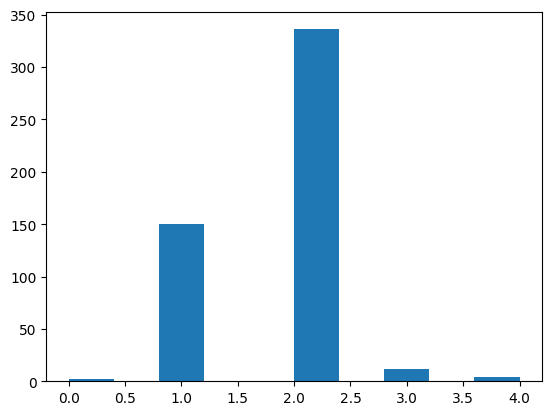

In [ ]:
plt.hist(nhy)
print(sum(nhy==0))

/tmp/ipykernel_14919/1995190623.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")


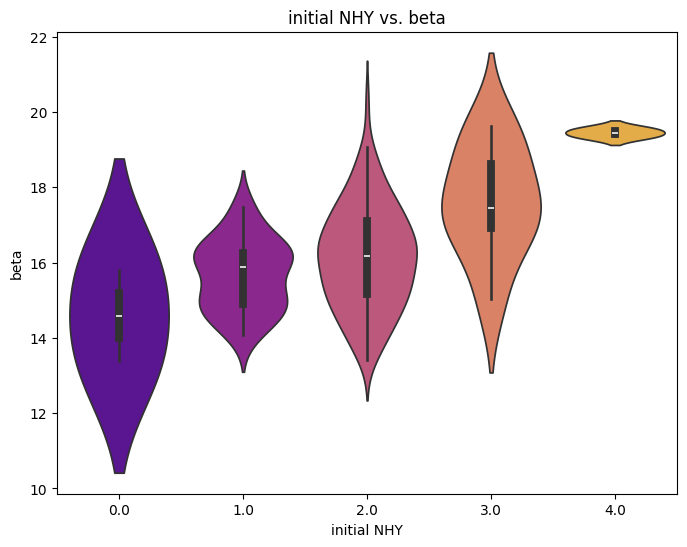

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_violin_nhy_vs_beta(ids, dt, nhy, beta):
    unique_ids = np.unique(ids)
    pair = []

    pid_to_beta = {pid: beta[i] for i, pid in enumerate(unique_ids)}

    for pid in unique_ids:
        mask = (ids == pid)
        dt_i = dt[mask]
        nhy_i = nhy[mask]
        idx_min_dt = np.argmax(dt_i)
        nhy_first = nhy_i[idx_min_dt]
        beta_i = pid_to_beta[pid]

        pair.append({"NHY": nhy_first, "beta": beta_i})

    df = pd.DataFrame(pair)

    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")
    plt.title("initial NHY vs. beta")
    plt.xlabel("initial NHY")
    plt.ylabel("beta")
    plt.show()

plot_violin_nhy_vs_beta(ids=ids, dt=dt, nhy=nhy, beta=beta_history[:, -1])
